In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('placement.csv')

df.sample(5)

,cgpa,placement_exam_marks,placed
820,6.27,16.0,0
17,7.56,22.0,1
654,7.03,76.0,0
740,6.21,74.0,1
368,7.09,32.0,0


In [3]:
df.shape

(1000, 3)

findfont: Failed to find font weight normal, now using 700.
findfont: Failed to find font weight normal, now using 700.


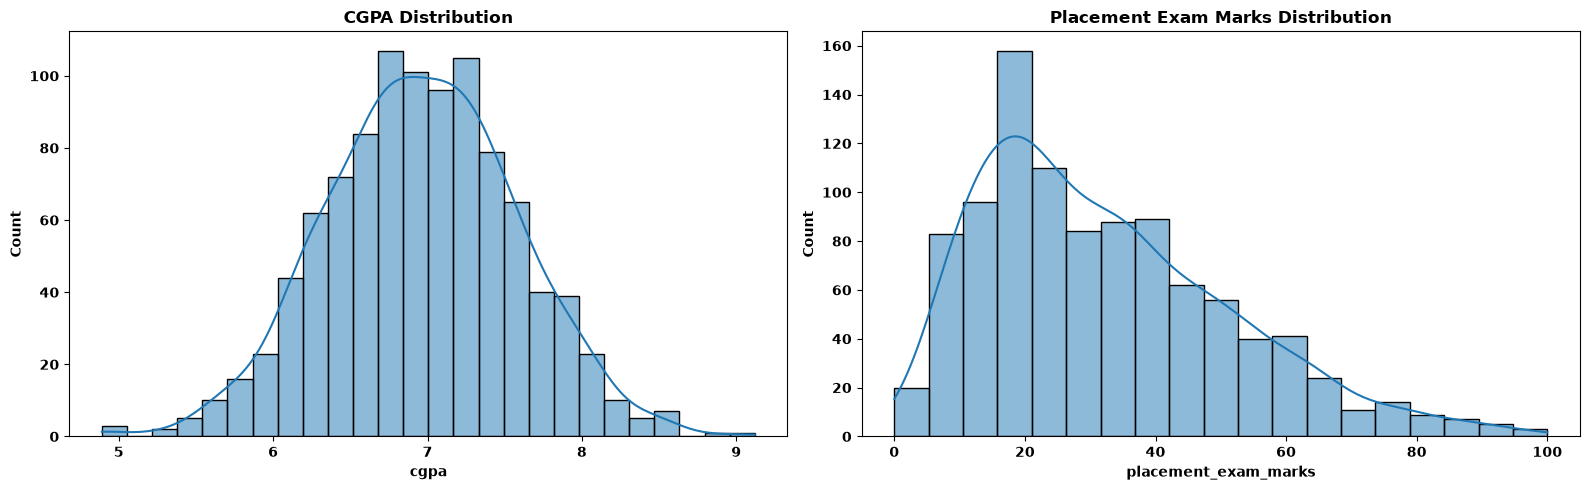

In [4]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.tight_layout()
plt.show()

In [ ]:
df['placement_exam_marks'].skew()  # it is right skew graph 

np.float64(0.8356419499466834)

In [6]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

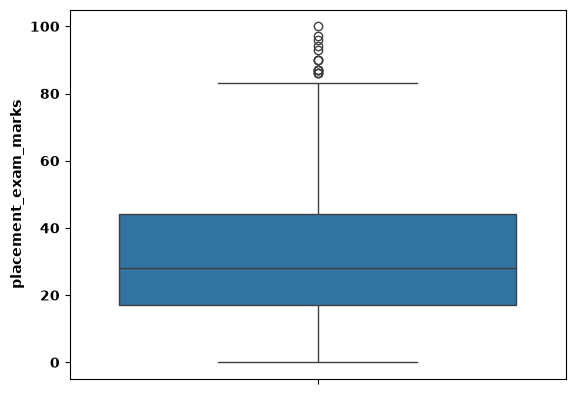

In [7]:
sns.boxplot(df['placement_exam_marks'])

In [9]:
# finding IQR 
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

print("Percentile 25: ", percentile25)
print("Percentile 75: ", percentile75)

Percentile 25:  17.0
Percentile 75:  44.0


In [10]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [11]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

print("Upper Limit: ", upper_limit)
print("Lower Limit: ", lower_limit)

Upper Limit:  84.5
Lower Limit:  -23.5


In [12]:
# Finding Outliers

df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [13]:
df[df['placement_exam_marks'] > lower_limit]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [14]:
# Implement technique like Capping and Trimming to fix outliers
# capping is use 

new_df = df.copy()
new_df['placement_exam_marks'] = np.where(
    new_df["placement_exam_marks"] > upper_limit,
    upper_limit,
    np.where(
        new_df['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df['placement_exam_marks']
    )
)

In [15]:
new_df.shape

(1000, 3)

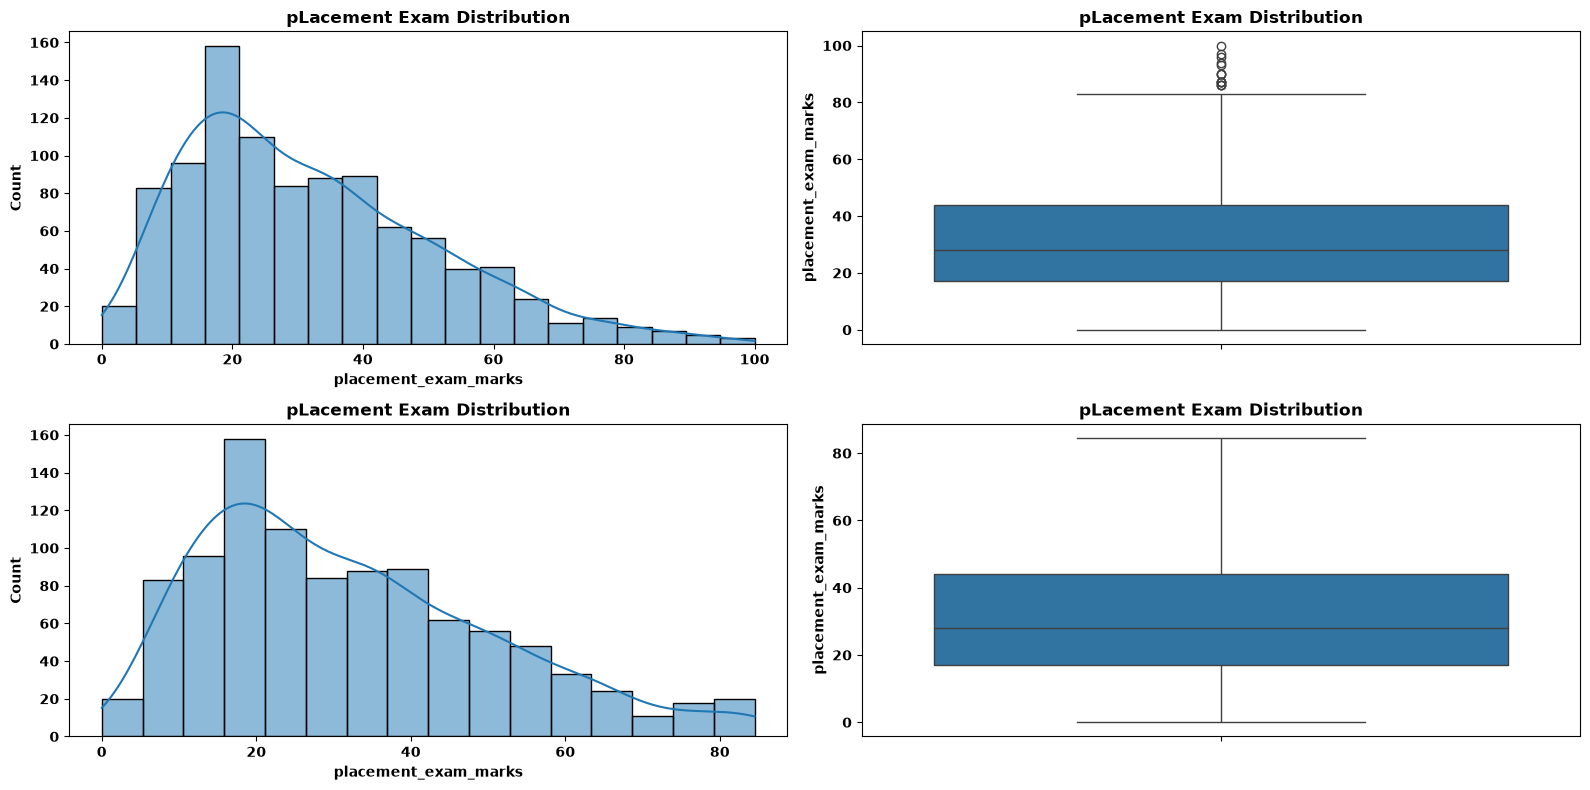

In [17]:
#comparing

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('pLacement Exam Distribution')

plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])
plt.title('pLacement Exam Distribution')

plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title('pLacement Exam Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(new_df['placement_exam_marks'])
plt.title('pLacement Exam Distribution')

plt.tight_layout()
plt.show()